# Summer 2026 Kaggle Regression

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV, LinearRegression, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

In [43]:
import numpy as np
import pandas as pd

train = pd.read_csv("summer2026_kaggle_linear_regression_challenge_train.csv")
train.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,target,Id
0,6.069,-0.331,2.142,-0.303,8.383,-1.911,-16.510,6.700,7.527,-0.501,13.442,-0.493,15.025,8.681,7.177,3.357,-10.688,1.332,-16.148,-25.791,-24.550,3
1,27.462,0.633,8.818,-2.926,10.120,1.937,-8.207,9.626,2.189,3.672,5.649,-3.100,0.530,-15.306,0.295,-1.847,13.650,18.232,6.594,-26.834,132.397,5
2,6.347,-4.329,4.631,0.293,-10.921,-3.541,11.793,29.883,-0.215,1.194,-4.327,-1.511,-16.140,0.746,2.611,-1.104,1.368,-4.848,13.752,-1.104,-104.831,6
3,3.209,3.765,2.011,0.748,-18.280,NaN,26.921,5.506,4.436,1.441,NaN,-4.184,-7.787,5.924,10.795,1.136,3.781,-9.039,10.646,NaN,-154.763,7
4,25.896,-1.500,0.977,-0.837,9.532,-0.465,-1.745,-2.162,-7.013,3.034,-9.647,12.368,12.997,1.708,-37.483,0.131,9.434,5.089,-6.645,29.236,-8.335,9


## 1. Load The Training Dataset

In [44]:
train_path = "summer2026_kaggle_linear_regression_challenge_train.csv"

train = pd.read_csv(train_path)
train.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,target,Id
0,6.069,-0.331,2.142,-0.303,8.383,-1.911,-16.510,6.700,7.527,-0.501,13.442,-0.493,15.025,8.681,7.177,3.357,-10.688,1.332,-16.148,-25.791,-24.550,3
1,27.462,0.633,8.818,-2.926,10.120,1.937,-8.207,9.626,2.189,3.672,5.649,-3.100,0.530,-15.306,0.295,-1.847,13.650,18.232,6.594,-26.834,132.397,5
2,6.347,-4.329,4.631,0.293,-10.921,-3.541,11.793,29.883,-0.215,1.194,-4.327,-1.511,-16.140,0.746,2.611,-1.104,1.368,-4.848,13.752,-1.104,-104.831,6
3,3.209,3.765,2.011,0.748,-18.280,NaN,26.921,5.506,4.436,1.441,NaN,-4.184,-7.787,5.924,10.795,1.136,3.781,-9.039,10.646,NaN,-154.763,7
4,25.896,-1.500,0.977,-0.837,9.532,-0.465,-1.745,-2.162,-7.013,3.034,-9.647,12.368,12.997,1.708,-37.483,0.131,9.434,5.089,-6.645,29.236,-8.335,9


In [45]:
print(f"Rows: {train.shape[0]}")
print(f"Columns: {train.shape[1]}")

train.info()

Rows: 2500
Columns: 22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      2478 non-null   float64
 1   x1      2479 non-null   float64
 2   x2      2475 non-null   float64
 3   x3      2478 non-null   float64
 4   x4      2473 non-null   float64
 5   x5      2469 non-null   float64
 6   x6      2476 non-null   float64
 7   x7      2485 non-null   float64
 8   x8      2480 non-null   float64
 9   x9      2472 non-null   float64
 10  x10     2475 non-null   float64
 11  x11     2474 non-null   float64
 12  x12     2483 non-null   float64
 13  x13     2476 non-null   float64
 14  x14     2479 non-null   float64
 15  x15     2470 non-null   float64
 16  x16     2470 non-null   float64
 17  x17     2471 non-null   float64
 18  x18     2475 non-null   float64
 19  x19     2471 non-null   float64
 20  target  2500 non-null   float64
 21  Id      2500 n

## 2. Basic Statistics

The `describe()` table gives the count, mean, standard deviation, min, max, and quartiles for each numeric column.

In [46]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
x0,2478.0,0.370,12.181,-41.102,-7.709,0.630,8.378,45.473
x1,2479.0,0.073,3.923,-11.863,-2.609,0.069,2.682,13.916
x2,2475.0,0.172,10.458,-44.496,-7.006,0.376,7.260,33.730
x3,2478.0,-0.011,1.868,-6.714,-1.300,-0.022,1.285,6.206
x4,2473.0,-0.120,9.757,-34.224,-6.920,0.224,6.622,27.218
x5,2469.0,-0.040,2.688,-10.246,-1.851,-0.114,1.746,8.186
x6,2476.0,0.101,14.164,-47.955,-9.780,-0.167,9.465,59.323
x7,2485.0,0.202,14.377,-55.423,-9.637,0.268,9.620,52.877
x8,2480.0,-0.035,4.290,-15.795,-2.860,-0.058,2.912,15.874
x9,2472.0,-0.066,3.651,-14.736,-2.459,-0.074,2.269,12.169


In [47]:
feature_cols = [col for col in train.columns if col.startswith("x")]
target_col = "target"
id_col = "Id"

print(f"Number of feature columns: {len(feature_cols)}")
print(feature_cols)

Number of feature columns: 20
['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19']


## 3. Missing Values

Missing values matter because many scikit-learn models cannot train on `NaN` values directly. We will likely need an imputer later.

In [48]:
missing_summary = (
    train.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda df: 100 * df["missing_count"] / len(train))
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_percent
x5,31,1.24
x16,30,1.20
x15,30,1.20
x19,29,1.16
x17,29,1.16
x9,28,1.12
x4,27,1.08
x11,26,1.04
x10,25,1.00
x2,25,1.00


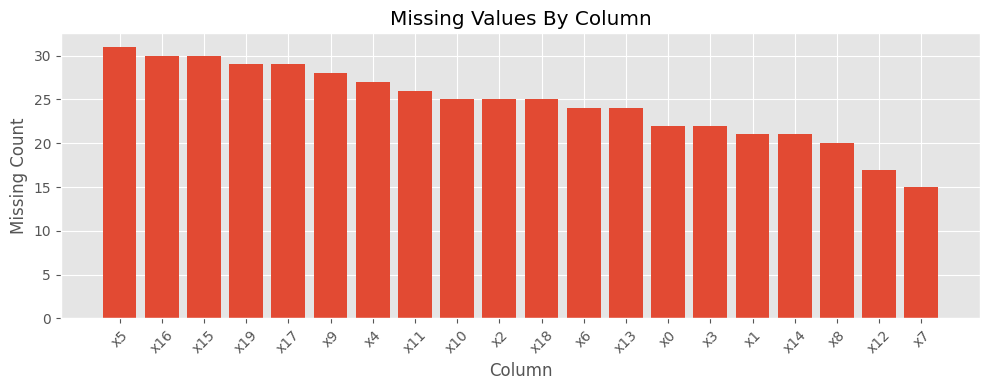

In [49]:
missing_plot = missing_summary[missing_summary["missing_count"] > 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(missing_plot.index, missing_plot["missing_count"])
ax.set_title("Missing Values By Column")
ax.set_xlabel("Column")
ax.set_ylabel("Missing Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4. Target Distribution

This shows how the value we want to predict is distributed.

In [50]:
train[target_col].describe()

count    2500.000
mean        1.777
std       149.001
min     -1215.473
25%       -75.011
50%        -0.101
75%        72.747
max       968.431
Name: target, dtype: float64

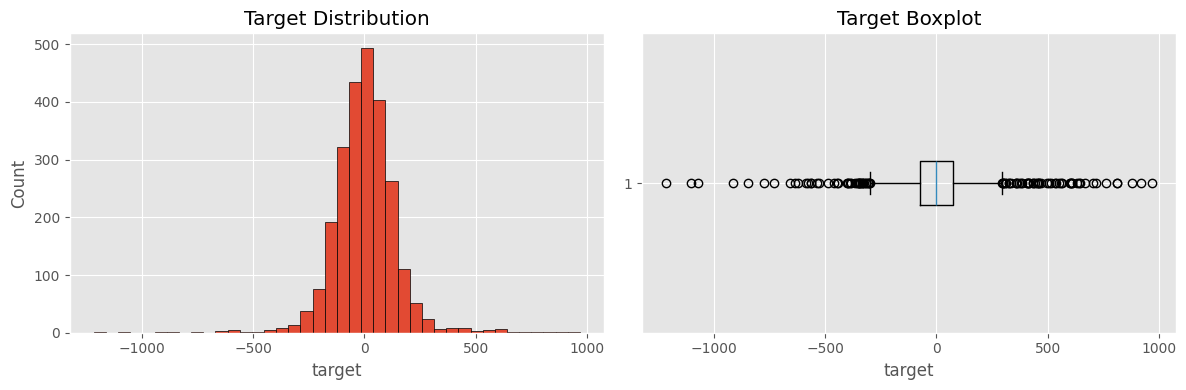

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train[target_col], bins=40, edgecolor="black")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("target")
axes[0].set_ylabel("Count")

axes[1].boxplot(train[target_col].dropna(), vert=False)
axes[1].set_title("Target Boxplot")
axes[1].set_xlabel("target")

plt.tight_layout()
plt.show()

## 5. Feature Distributions

A quick histogram grid helps us see whether features are centered, skewed, or have unusual outliers.

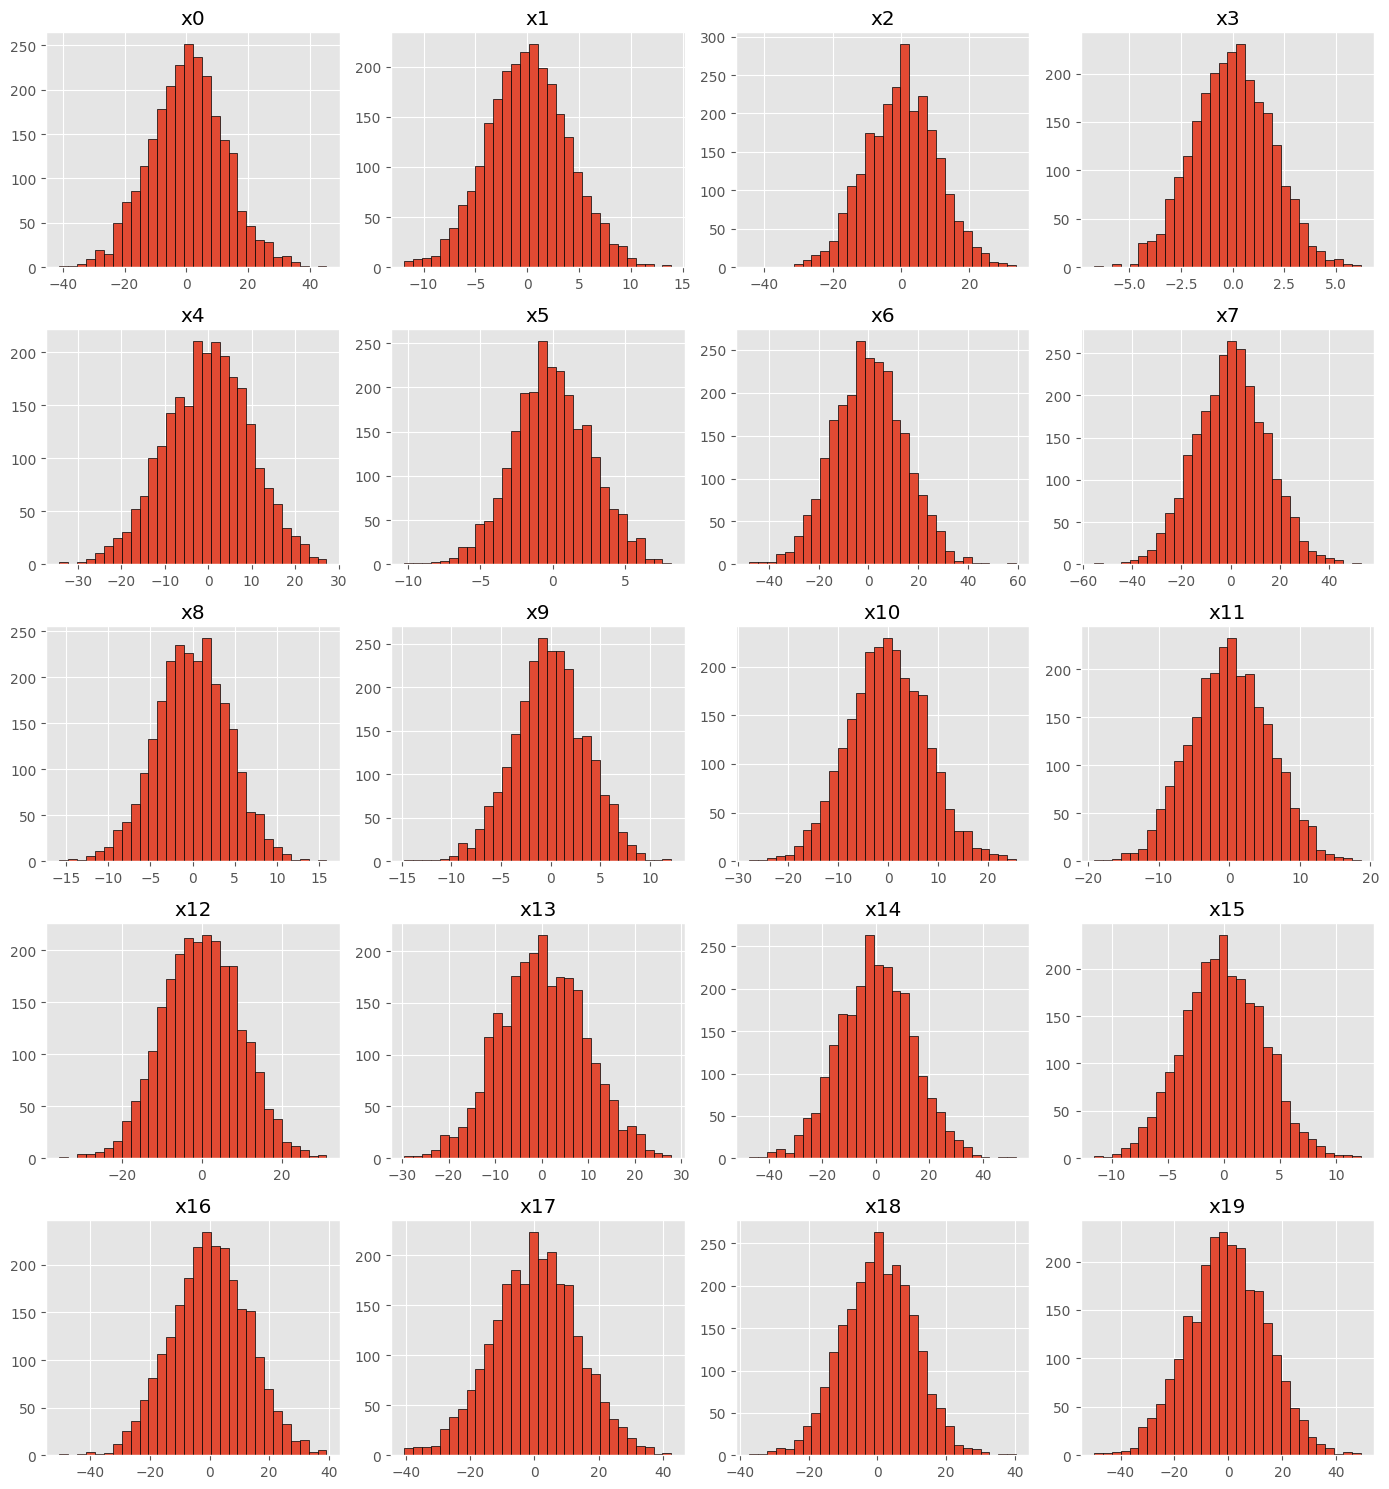

In [52]:
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(train[col].dropna(), bins=30, edgecolor="black")
    axes[i].set_title(col)

for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 6. Correlation With Target

This is a simple way to see which individual features have the strongest linear relationship with `target`.

In [53]:
target_corr = (
    train[feature_cols + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

target_corr.mul(100).round(2).to_frame("correlation_with_target (%)")

,correlation_with_target (%)
x17,39.10
x16,30.79
x0,-23.43
x4,22.64
x2,-21.16
x13,-19.51
x18,15.86
x6,-15.71
x14,-15.33
x19,-14.87


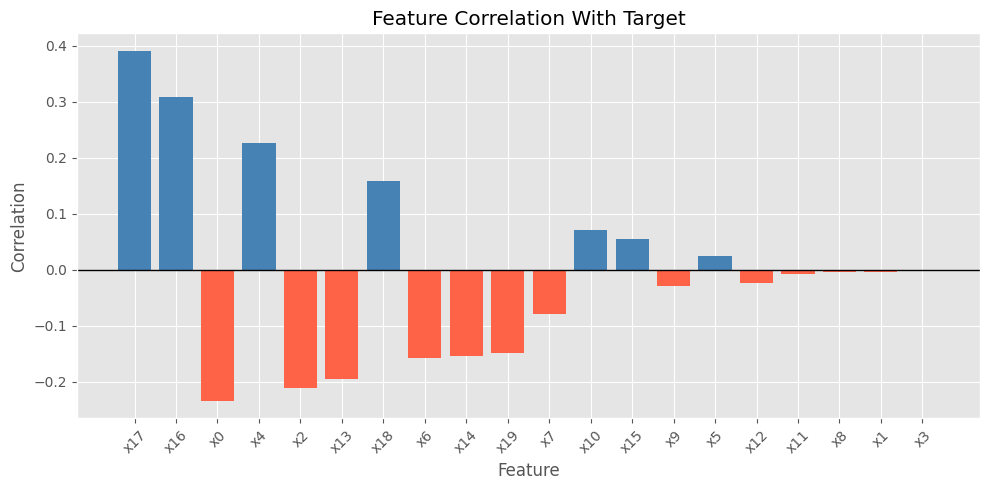

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = np.where(target_corr >= 0, "steelblue", "tomato")

ax.bar(target_corr.index, target_corr.values, color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Feature Correlation With Target")
ax.set_xlabel("Feature")
ax.set_ylabel("Correlation")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

The heatmap shows linear relationships between features and the target.

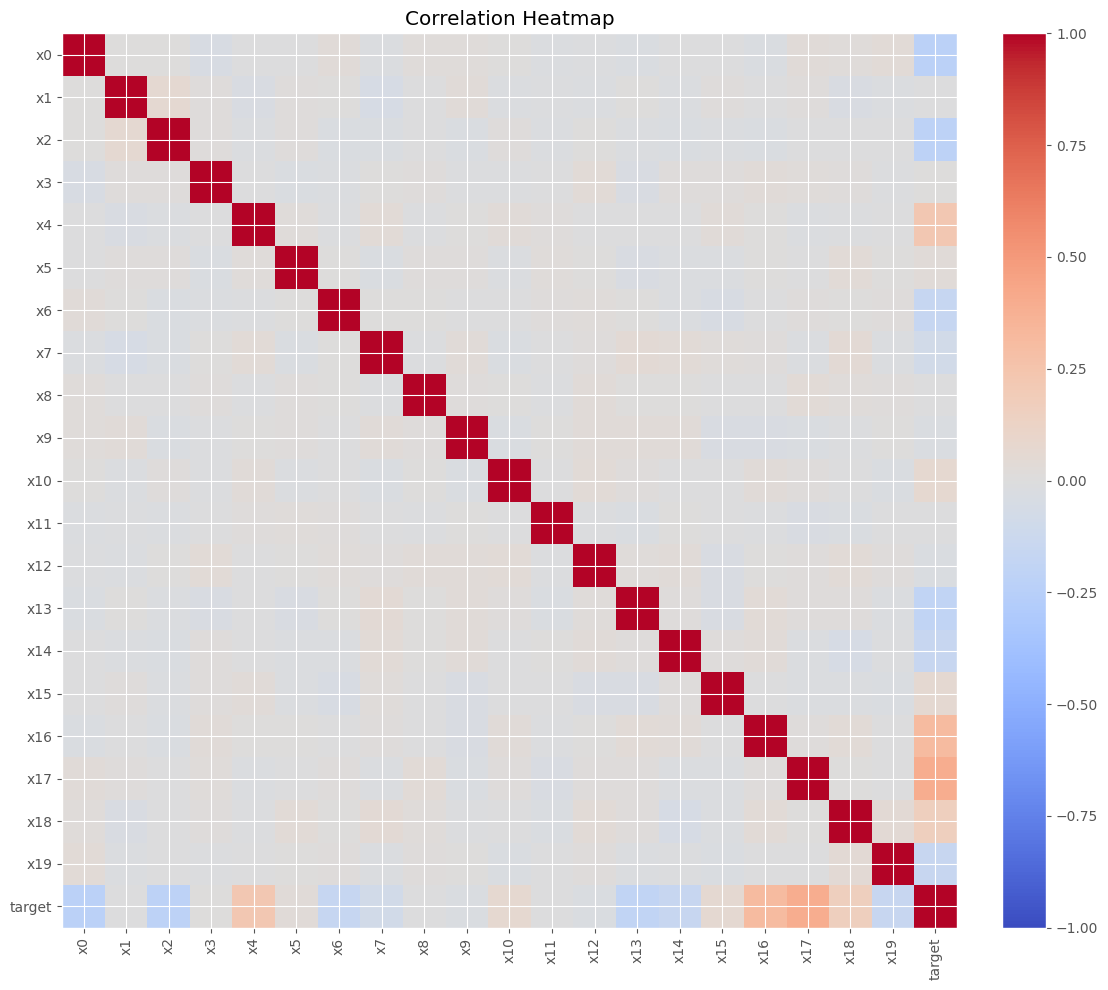

In [55]:
corr = train[feature_cols + [target_col]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation Heatmap")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 8. Scatter Plots For Strongest Features

These scatter plots compare the top correlated features against the target.

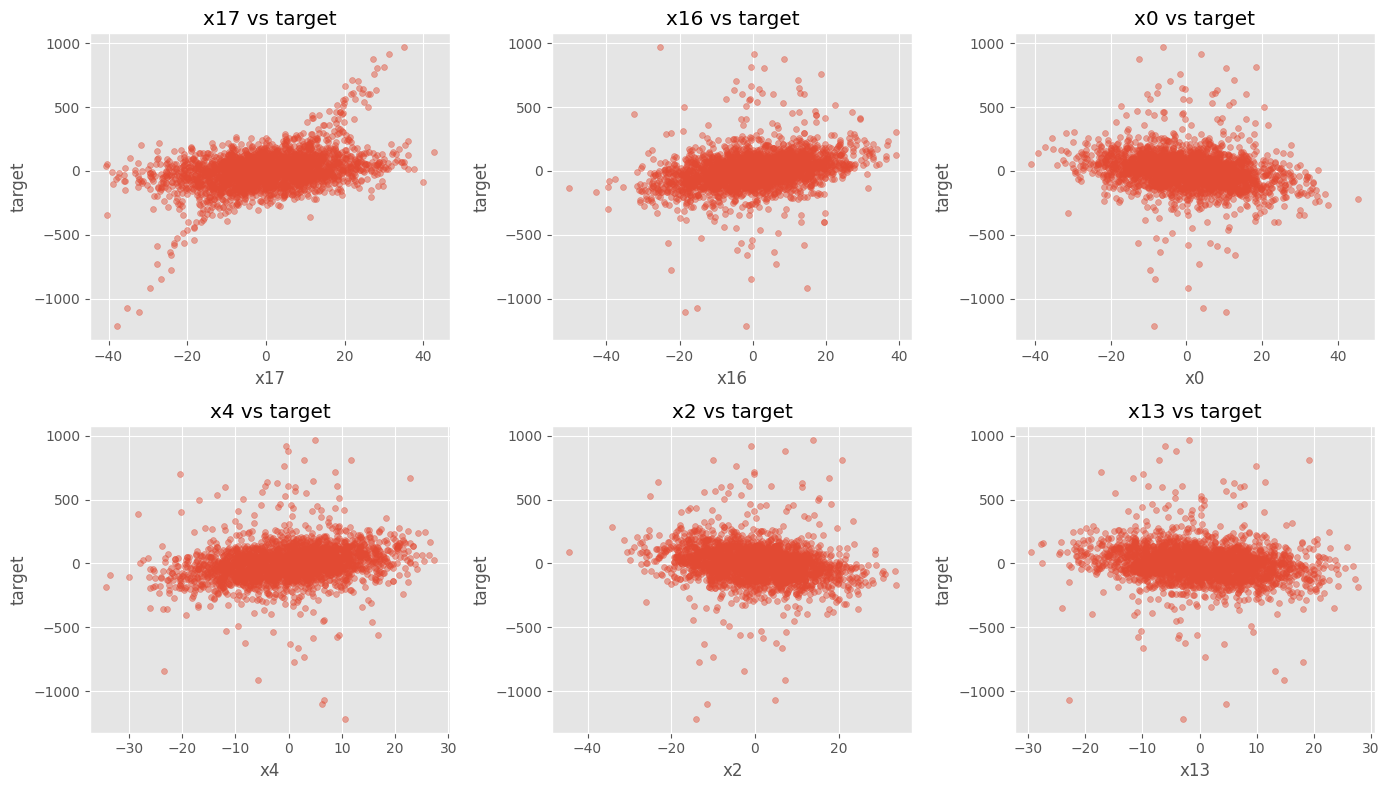

In [56]:
top_features = target_corr.abs().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    ax.scatter(train[col], train[target_col], alpha=0.45, s=18)
    ax.set_title(f"{col} vs target")
    ax.set_xlabel(col)
    ax.set_ylabel("target")

plt.tight_layout()
plt.show()

## 9. Quick Takeaways To Fill In

After running the notebook, write a few observations here:

- Dataset size:
- Missing value pattern:
- Target distribution:
- Most correlated features:
- Any visible outliers:

In [57]:
# Baseline CV R^2 using all features (unstandardized)
X_all = train.drop(columns=["target", "Id"]).copy()
y_all = train["target"]

# Keep original scales; only impute missing values for model compatibility
X_all = X_all.fillna(X_all.median())

baseline_model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = cross_val_score(baseline_model, X_all, y_all, cv=cv, scoring="r2")

print("Baseline CV R^2 using all unstandardized features:")
print(f"Fold scores: {cv_r2_scores.round(4)}")
print(f"Mean CV R^2: {cv_r2_scores.mean():.4f} +/- {cv_r2_scores.std():.4f}")

Baseline CV R^2 using all unstandardized features:
Fold scores: [0.5073 0.5447 0.4782 0.4927 0.6769]
Mean CV R^2: 0.5400 +/- 0.0720


In [58]:
# Quick regression check with top 10 correlated features
X = train.drop(columns=["target", "Id"]).copy()
y = train["target"]

# Absolute correlation with target
corr = X.corrwith(y).abs().sort_values(ascending=False)
top10 = corr.head(10)

# Fill missing values using median
X_top10 = X[top10.index].copy()
X_top10 = X_top10.fillna(X_top10.median())

# Fit model
model = LinearRegression()
model.fit(X_top10, y)

# Predict on training set
y_pred = model.predict(X_top10)

# Compute R^2
r2_train = r2_score(y, y_pred)

print("Top 10 features by absolute correlation with target:")
print(top10.round(6))
print(f"\nTraining set R^2: {r2_train:.4f}")

Top 10 features by absolute correlation with target:
x17    0.391
x16    0.308
x0     0.234
x4     0.226
x2     0.212
x13    0.195
x18    0.159
x6     0.157
x14    0.153
x19    0.149
dtype: float64

Training set R^2: 0.5288


In [59]:
train = pd.read_csv("summer2026_kaggle_linear_regression_challenge_train.csv")

X = train.drop(columns=["target", "Id"]).copy()
y = train["target"]

# median imputation before split is okay, but do it consistently
X = X.fillna(X.median())

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

model.fit(X_train, y_train)
y_pred = model.predict(X_valid)

print("Validation R^2:", r2_score(y_valid, y_pred))

Validation R^2: 0.50726574633882


Best alpha (regularization strength): 1.149246

Features selected by Lasso: 19 / 20
Features zeroed out:        1

Top features by |coefficient|:
x17    53.426
x16    41.994
x0     34.523
x4     33.152
x13    31.597
x2     29.636
x6     23.043
x19    19.846
x14    19.697
x18    18.571
x7      9.932
x10     7.598
x15     4.510
x3      1.943
x12     1.025
x8      1.010
x1      0.398
x5      0.281
x9      0.209

Lasso Validation R2: 0.5024


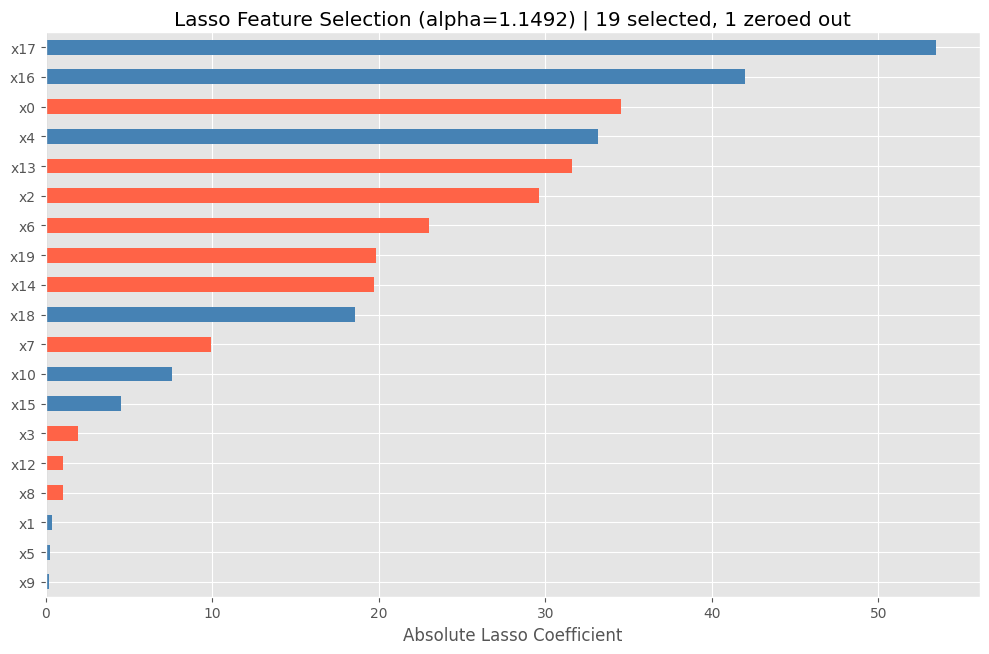

In [60]:
# LassoCV automatically finds the best alpha via 5-fold cross-validation
lasso_cv = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=10000)
)
lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.named_steps["lassocv"].alpha_
print(f"Best alpha (regularization strength): {best_alpha:.6f}")

# Extract coefficients mapped to feature names
lasso_coefs = pd.Series(
    lasso_cv.named_steps["lassocv"].coef_,
    index=X_train.columns
)

# Features kept by Lasso (non-zero coefficient), sorted by importance
selected = lasso_coefs[lasso_coefs != 0].abs().sort_values(ascending=False)
zeroed_out = lasso_coefs[lasso_coefs == 0]

print(f"\nFeatures selected by Lasso: {len(selected)} / {len(lasso_coefs)}")
print(f"Features zeroed out:        {len(zeroed_out)}")
print("\nTop features by |coefficient|:")
print(selected.to_string())

# Validation R2
y_pred_lasso = lasso_cv.predict(X_valid)
print(f"\nLasso Validation R2: {r2_score(y_valid, y_pred_lasso):.4f}")

# Bar chart of selected features
fig, ax = plt.subplots(figsize=(10, max(4, len(selected) * 0.35)))
bar_colors = ["steelblue" if lasso_coefs[f] > 0 else "tomato" for f in selected.index]
selected.plot(kind="barh", ax=ax, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Absolute Lasso Coefficient")
ax.set_title(f"Lasso Feature Selection (alpha={best_alpha:.4f}) | {len(selected)} selected, {len(zeroed_out)} zeroed out")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Model Comparison and Standardized Features

All features are standardized (zero mean, unit variance). We use 5-fold cross-validation **within the training set** for each method, then compare CV R2 scores.

In [61]:
# Standardize all features on the training set
scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_valid_sc = pd.DataFrame(
    scaler.transform(X_valid),
    columns=X_valid.columns, index=X_valid.index
)

cv_results = {}   # shared dict to collect each method's CV R2

print('X_train_sc shape:', X_train_sc.shape)
print('X_valid_sc shape:', X_valid_sc.shape)
print(X_train_sc.describe().round(3))

X_train_sc shape: (2000, 20)
X_valid_sc shape: (500, 20)
             x0        x1        x2        x3        x4        x5        x6  \
count  2000.000  2000.000  2000.000  2000.000  2000.000  2000.000  2000.000   
mean      0.000     0.000     0.000     0.000     0.000    -0.000     0.000   
std       1.000     1.000     1.000     1.000     1.000     1.000     1.000   
min      -3.438    -3.055    -4.326    -3.123    -3.487    -3.426    -3.399   
25%      -0.653    -0.675    -0.671    -0.698    -0.690    -0.667    -0.669   
50%       0.006     0.001     0.023    -0.014     0.038    -0.024    -0.003   
75%       0.647     0.668     0.675     0.697     0.690     0.645     0.650   
max       3.705     3.547     3.255     3.173     2.799     2.919     4.224   

             x7        x8        x9       x10       x11       x12       x13  \
count  2000.000  2000.000  2000.000  2000.000  2000.000  2000.000  2000.000   
mean      0.000    -0.000     0.000     0.000    -0.000    -0.000    -0.0

### Method a Lasso Feature Selection (top 10) + Linear Regression

LassoCV selects features by shrinking coefficients to zero. We keep the top 10 by absolute coefficient and then fit a plain Linear Regression on those features, evaluated via 5-fold CV on the training set.

In [62]:
# Step 1: LassoCV on standardized training data to rank/select features
lasso_selector = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_selector.fit(X_train_sc, y_train)

best_alpha = lasso_selector.alpha_
coefs = pd.Series(lasso_selector.coef_, index=X_train_sc.columns)
top10_features = coefs.abs().sort_values(ascending=False).head(10).index.tolist()

print(f'Best Lasso alpha: {best_alpha:.4f}')
print('Top 10 features selected by Lasso:')
print(coefs[top10_features].abs().sort_values(ascending=False).round(3).to_string())

# Step 2: Linear Regression on the top 10 features, 5-fold CV on training set
lr_lasso = LinearRegression()
cv_scores_lasso = cross_val_score(
    lr_lasso, X_train_sc[top10_features], y_train,
    cv=5, scoring='r2'
)

print(f'\n5-fold CV R2 scores: {cv_scores_lasso.round(4)}')
print(f'Mean CV R2: {cv_scores_lasso.mean():.4f}  (+/- {cv_scores_lasso.std():.4f})')

# Held-out validation R2
lr_lasso.fit(X_train_sc[top10_features], y_train)
val_r2_lasso = r2_score(y_valid, lr_lasso.predict(X_valid_sc[top10_features]))
print(f'Validation R2:  {val_r2_lasso:.4f}')

cv_results['Lasso Top10 + LR'] = {'mean_cv_r2': cv_scores_lasso.mean(), 'std': cv_scores_lasso.std(), 'val_r2': val_r2_lasso}

Best Lasso alpha: 1.1492
Top 10 features selected by Lasso:
x17    53.426
x16    41.994
x0     34.523
x4     33.152
x13    31.597
x2     29.636
x6     23.043
x19    19.846
x14    19.697
x18    18.571

5-fold CV R2 scores: [0.5676 0.4379 0.4563 0.5985 0.6593]
Mean CV R2: 0.5439  (+/- 0.0846)
Validation R2:  0.4926


### Method b PCA + Linear Regression

We apply PCA to the standardized features to find the number of components that explain 95% of variance, then fit a Linear Regression on those components, evaluated via 5-fold CV on the training set.

Components explaining 95% of variance: 19
Explained variance ratios: [0.059 0.058 0.056 0.055 0.055 0.054 0.052 0.052 0.051 0.05  0.049 0.048
 0.048 0.047 0.047 0.046 0.045 0.043 0.043]


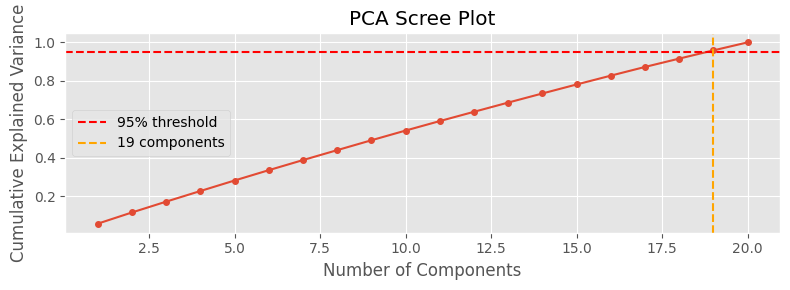


5-fold CV R2 scores: [0.5157 0.3973 0.3656 0.5802 0.6569]
Mean CV R2: 0.5031  (+/- 0.1094)
Validation R2:  0.4209


In [63]:
# Step 1: Fit PCA and choose components that explain 95% of variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cumvar, 0.95)) + 1
print(f'Components explaining 95% of variance: {n_components}')
print(f'Explained variance ratios: {pca_full.explained_variance_ratio_[:n_components].round(3)}')

# Scree plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4)
ax.axhline(0.95, color='red', linestyle='--', label='95% threshold')
ax.axvline(n_components, color='orange', linestyle='--', label=f'{n_components} components')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Scree Plot')
ax.legend()
plt.tight_layout()
plt.show()

# Step 2: PCA + Linear Regression pipeline, 5-fold CV on training set
pca_lr = make_pipeline(PCA(n_components=n_components, random_state=42), LinearRegression())
cv_scores_pca = cross_val_score(
    pca_lr, X_train_sc, y_train,
    cv=5, scoring='r2'
)

print(f'\n5-fold CV R2 scores: {cv_scores_pca.round(4)}')
print(f'Mean CV R2: {cv_scores_pca.mean():.4f}  (+/- {cv_scores_pca.std():.4f})')

# Held-out validation R2
pca_lr.fit(X_train_sc, y_train)
val_r2_pca = r2_score(y_valid, pca_lr.predict(X_valid_sc))
print(f'Validation R2:  {val_r2_pca:.4f}')

cv_results['PCA + LR'] = {'mean_cv_r2': cv_scores_pca.mean(), 'std': cv_scores_pca.std(), 'val_r2': val_r2_pca}

### Method Comparison

Summary of 5-fold CV R2 and held-out validation R2 for each method.

Method Comparison
-------------------------------------------------------
Method                    CV R2 (mean)  CV R2 (std)   Val R2
-------------------------------------------------------
Lasso Top10 + LR                0.5439       0.0846   0.4926
PCA + LR                        0.5031       0.1094   0.4209


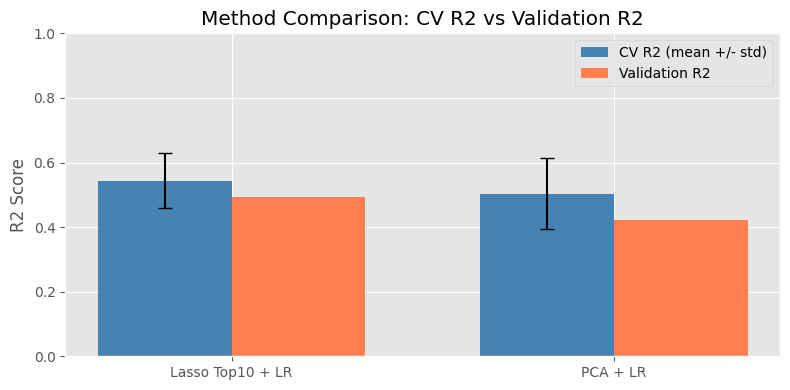

In [64]:
methods = list(cv_results.keys())
mean_cvs = [cv_results[m]['mean_cv_r2'] for m in methods]
stds     = [cv_results[m]['std']         for m in methods]
val_r2s  = [cv_results[m]['val_r2']      for m in methods]

print('Method Comparison')
print('-' * 55)
print(f"{'Method':<25} {'CV R2 (mean)':>12} {'CV R2 (std)':>12} {'Val R2':>8}")
print('-' * 55)
for m in methods:
    r = cv_results[m]
    print(f'{m:<25} {r["mean_cv_r2"]:>12.4f} {r["std"]:>12.4f} {r["val_r2"]:>8.4f}')

x = np.arange(len(methods))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, mean_cvs, width, yerr=stds, capsize=5, label='CV R2 (mean +/- std)', color='steelblue')
bars2 = ax.bar(x + width/2, val_r2s,  width, label='Validation R2', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('R2 Score')
ax.set_title('Method Comparison: CV R2 vs Validation R2')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Prediction 1 LASSO

In [65]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# Rebuild the train/validation split from the raw training data so imputation uses
# training-set means only.
X_raw = train.drop(columns=["target", "Id"]).copy()
y_raw = train["target"].copy()

X_train_lasso, X_valid_lasso, y_train_lasso, y_valid_lasso = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# 1) Impute missing independent-variable values with training-set means.
imputer = SimpleImputer(strategy="mean")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_lasso),
    columns=X_train_lasso.columns,
    index=X_train_lasso.index,
)
X_valid_imp = pd.DataFrame(
    imputer.transform(X_valid_lasso),
    columns=X_valid_lasso.columns,
    index=X_valid_lasso.index,
)

# 2) Standardize all independent variables using training-set statistics.
scaler = StandardScaler()
X_train_lasso_sc = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns,
    index=X_train_imp.index,
)
X_valid_lasso_sc = pd.DataFrame(
    scaler.transform(X_valid_imp),
    columns=X_valid_imp.columns,
    index=X_valid_imp.index,
)

# 3) Fit a Lasso model and choose alpha by cross-validation.
cv = KFold(n_splits=5, shuffle=True, random_state=42)
lasso_cv_mean = LassoCV(cv=cv, random_state=42, max_iter=10000)
lasso_cv_mean.fit(X_train_lasso_sc, y_train_lasso)

y_valid_pred = lasso_cv_mean.predict(X_valid_lasso_sc)
lasso_mean_coefs = pd.Series(lasso_cv_mean.coef_, index=X_train_lasso_sc.columns)

print(f"Best alpha from CV: {lasso_cv_mean.alpha_:.6f}")
print(f"Number of non-zero coefficients: {(lasso_mean_coefs != 0).sum()} / {len(lasso_mean_coefs)}")
print(f"Validation R^2: {r2_score(y_valid_lasso, y_valid_pred):.4f}")
print("\nTop features by |coefficient|:")
print(lasso_mean_coefs.abs().sort_values(ascending=False).head(10).round(4).to_string())


Best alpha from CV: 0.284693
Number of non-zero coefficients: 19 / 20
Validation R^2: 0.5064

Top features by |coefficient|:
x17    54.352
x16    42.862
x0     35.454
x4     33.932
x13    32.501
x2     30.473
x6     23.882
x19    20.660
x14    20.481
x18    19.529


In [66]:
from sklearn.linear_model import Lasso

best_alpha_full = lasso_cv_mean.alpha_

# Refit Lasso on the full training data using the best alpha found above.
X_full_raw = train.drop(columns=["target", "Id"]).copy()
y_full = train["target"].copy()

full_train_imputer = SimpleImputer(strategy="mean")
X_full_imp = pd.DataFrame(
    full_train_imputer.fit_transform(X_full_raw),
    columns=X_full_raw.columns,
    index=X_full_raw.index,
)

full_train_scaler = StandardScaler()
X_full_sc = pd.DataFrame(
    full_train_scaler.fit_transform(X_full_imp),
    columns=X_full_imp.columns,
    index=X_full_imp.index,
)

lasso_full = Lasso(alpha=best_alpha_full, max_iter=10000)
lasso_full.fit(X_full_sc, y_full)

y_full_pred = lasso_full.predict(X_full_sc)
train_r2_full = r2_score(y_full, y_full_pred)
lasso_full_coefs = pd.Series(lasso_full.coef_, index=X_full_sc.columns)

print(f"Best alpha used: {best_alpha_full:.6f}")
print(f"Training R^2 on full training data: {train_r2_full:.4f}")
print("\nLasso coefficients for each independent variable:")
print(lasso_full_coefs.round(6).to_string())


Best alpha used: 0.284693
Training R^2 on full training data: 0.5424

Lasso coefficients for each independent variable:
x0    -34.968
x1      0.967
x2    -31.201
x3     -4.783
x4     33.247
x5      0.622
x6    -23.350
x7    -12.452
x8     -1.053
x9      0.566
x10     7.511
x11    -0.000
x12    -2.651
x13   -31.907
x14   -22.044
x15     5.709
x16    43.557
x17    58.215
x18    23.070
x19   -21.656


Lasso coefficients for each raw feature, ranked by |coefficient|:
x17    58.215
x16    43.557
x0    -34.968
x4     33.247
x13   -31.907
x2    -31.201
x6    -23.350
x18    23.070
x14   -22.044
x19   -21.656
x7    -12.452
x10     7.511
x15     5.709
x3     -4.783
x12    -2.651
x8     -1.053
x1      0.967
x5      0.622
x9      0.566
x11    -0.000


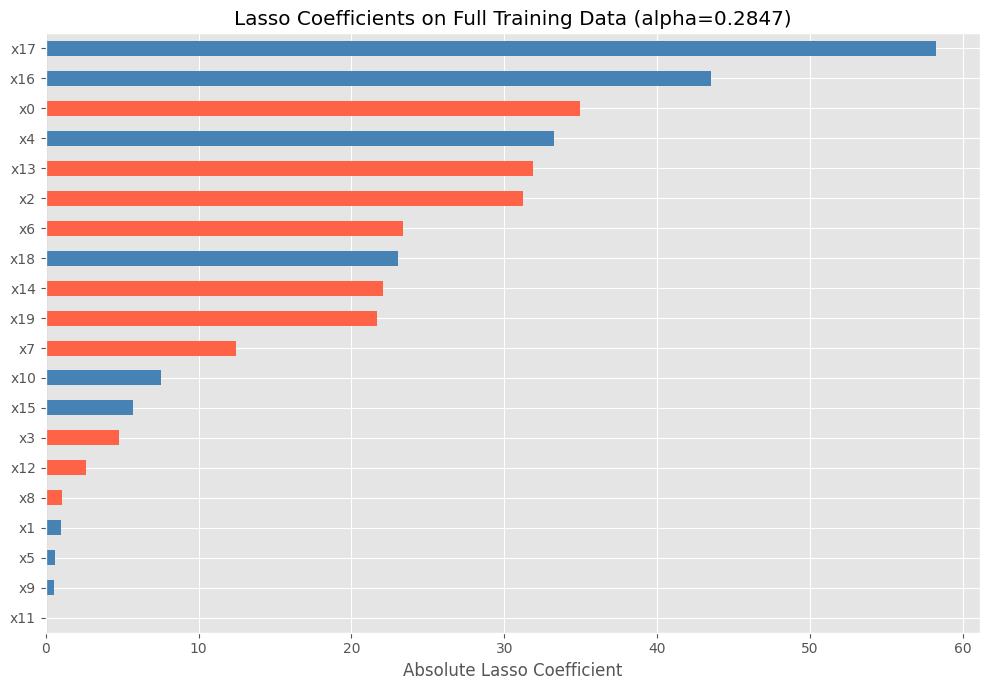

In [67]:
# Rank all raw feature coefficients from the full-data Lasso model by absolute value
lasso_full_coefs_ranked = lasso_full_coefs.abs().sort_values(ascending=False)

print("Lasso coefficients for each raw feature, ranked by |coefficient|:")
print(lasso_full_coefs.reindex(lasso_full_coefs_ranked.index).round(6).to_string())

# Bar chart of absolute Lasso coefficients, colored by sign of the raw coefficient
fig, ax = plt.subplots(figsize=(10, max(4, len(lasso_full_coefs_ranked) * 0.35)))
bar_colors = ["steelblue" if lasso_full_coefs[f] > 0 else "tomato" for f in lasso_full_coefs_ranked.index]
lasso_full_coefs_ranked.plot(kind="barh", ax=ax, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Absolute Lasso Coefficient")
ax.set_title(f"Lasso Coefficients on Full Training Data (alpha={best_alpha_full:.4f})")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
test = pd.read_csv("summer2026_kaggle_linear_regression_challenge_test.csv")

X_test_raw = test.drop(columns=["Id"]).copy()
X_test_imp = pd.DataFrame(
    full_train_imputer.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index,
)
X_test_sc = pd.DataFrame(
    full_train_scaler.transform(X_test_imp),
    columns=X_test_imp.columns,
    index=X_test_imp.index,
)

test_pred = lasso_full.predict(X_test_sc)

submission_lasso = pd.DataFrame({
    "Id": test["Id"],
    "target": test_pred,
})

output_path = "summer2026_lasso_predictions.csv"
submission_lasso.to_csv(output_path, index=False)

print(f"Predictions saved to: {output_path}")
print(submission_lasso.head())


Predictions saved to: summer2026_lasso_predictions.csv
   Id   target
0   0  244.621
1   1  -18.445
2   2   87.395
3   4   30.624
4   8 -330.527


Prediction 2 KNN

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

X_knn_raw = train.drop(columns=["target", "Id"]).copy()
y_knn = train["target"].copy()

X_train_knn, X_valid_knn, y_train_knn, y_valid_knn = train_test_split(
    X_knn_raw, y_knn, test_size=0.2, random_state=42
)

# Order: mean imputation -> standardization -> KNN regression.
# Putting preprocessing inside the pipeline prevents data leakage in CV.
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor()),
])

param_grid = {
    "knn__n_neighbors": [5, 7, 9, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv_knn = KFold(n_splits=5, shuffle=True, random_state=42)
knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv_knn,
    n_jobs=-1,
    return_train_score=True,
)

knn_search.fit(X_train_knn, y_train_knn)

knn_cv_results = pd.DataFrame(knn_search.cv_results_)
knn_cv_results["overfit_gap"] = (
    knn_cv_results["mean_train_score"] - knn_cv_results["mean_test_score"]
)
knn_cv_results["overfit_flag"] = np.where(
    knn_cv_results["overfit_gap"] > 0.10,
    "possible_overfit",
    "ok",
)
knn_cv_results = knn_cv_results.sort_values(
    ["mean_test_score", "overfit_gap"], ascending=[False, True]
)

# Among near-best CV models, choose the one with the smaller train-vs-CV gap.
cv_tolerance = 0.01
stable_knn_candidates = knn_cv_results[
    (knn_cv_results["mean_test_score"] >= knn_search.best_score_ - cv_tolerance)
    & (knn_cv_results["overfit_flag"] == "ok")
]

if stable_knn_candidates.empty:
    stable_knn_candidates = knn_cv_results.sort_values(
        ["overfit_gap", "mean_test_score"], ascending=[True, False]
    )

selected_knn_row = stable_knn_candidates.iloc[0]
selected_knn_params = {
    "knn__n_neighbors": int(selected_knn_row["param_knn__n_neighbors"]),
    "knn__weights": selected_knn_row["param_knn__weights"],
    "knn__p": int(selected_knn_row["param_knn__p"]),
}

best_knn_model = knn_pipeline.set_params(**selected_knn_params)
best_knn_model.fit(X_train_knn, y_train_knn)
y_valid_knn_pred = best_knn_model.predict(X_valid_knn)
valid_r2_knn = r2_score(y_valid_knn, y_valid_knn_pred)

print("Highest-CV KNN hyperparameters:", knn_search.best_params_)
print(f"Highest 5-fold CV R^2: {knn_search.best_score_:.4f}")
print("\nSelected KNN hyperparameters (avoid overfitting):", selected_knn_params)
print(f"Selected model CV R^2: {selected_knn_row['mean_test_score']:.4f}")
print(f"Train-CV gap for selected model: {selected_knn_row['overfit_gap']:.4f}")
print(f"Validation R^2: {valid_r2_knn:.4f}")
print("\nAll hyperparameter results:")
print(
    knn_cv_results[
        [
            "param_knn__n_neighbors",
            "param_knn__weights",
            "param_knn__p",
            "mean_test_score",
            "mean_train_score",
            "overfit_gap",
            "overfit_flag",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


Highest-CV KNN hyperparameters: {'knn__n_neighbors': 21, 'knn__p': 2, 'knn__weights': 'distance'}
Highest 5-fold CV R^2: 0.3437

Selected KNN hyperparameters (avoid overfitting): {'knn__n_neighbors': 21, 'knn__weights': 'uniform', 'knn__p': 2}
Selected model CV R^2: 0.3421
Train-CV gap for selected model: 0.0555
Validation R^2: 0.2887

All hyperparameter results:
 param_knn__n_neighbors param_knn__weights  param_knn__p  mean_test_score  mean_train_score  overfit_gap     overfit_flag
                     21           distance             2            0.344             1.000        0.656 possible_overfit
                     15           distance             2            0.342             1.000        0.658 possible_overfit
                     21            uniform             2            0.342             0.398        0.056               ok
                     15            uniform             2            0.341             0.421        0.080               ok
                     31 

In [28]:
X_knn_full_raw = train.drop(columns=["target", "Id"]).copy()
y_knn_full = train["target"].copy()

# Refit the selected KNN model on all training data.
# The pipeline applies mean imputation first, then standardization, then KNN.
knn_full_model = knn_pipeline.set_params(**selected_knn_params)
knn_full_model.fit(X_knn_full_raw, y_knn_full)

y_knn_full_pred = knn_full_model.predict(X_knn_full_raw)
full_train_r2_knn = r2_score(y_knn_full, y_knn_full_pred)

print("Selected KNN hyperparameters used on full training data:")
print(selected_knn_params)
print(f"Full training R^2: {full_train_r2_knn:.4f}")


Selected KNN hyperparameters used on full training data:
{'knn__n_neighbors': 21, 'knn__weights': 'uniform', 'knn__p': 2}
Full training R^2: 0.3976


Prediction 3 Random Forest

In [29]:
from sklearn.ensemble import RandomForestRegressor

X_rf_raw = train.drop(columns=["target", "Id"]).copy()
y_rf = train["target"].copy()

# Order: mean imputation -> standardization -> random forest.
# Preprocessing stays inside the pipeline so each CV fold learns from its own training fold only.
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

# Keep the search simple: tune only 3 basic hyperparameters.
param_grid_rf = {
    "rf__n_estimators": [200],
    "rf__max_depth": [4, 8, None],
    "rf__min_samples_leaf": [1, 3, 5],
}

cv_rf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="r2",
    cv=cv_rf,
    n_jobs=-1,
    return_train_score=True,
)

rf_search.fit(X_rf_raw, y_rf)

rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results["overfit_gap"] = (
    rf_cv_results["mean_train_score"] - rf_cv_results["mean_test_score"]
)
rf_cv_results["overfit_flag"] = np.where(
    rf_cv_results["overfit_gap"] > 0.10,
    "possible_overfit",
    "ok",
)
rf_cv_results = rf_cv_results.sort_values(
    ["mean_test_score", "overfit_gap"], ascending=[False, True]
)

# Among near-best CV models, choose the one with smaller overfit gap.
cv_tolerance_rf = 0.01
stable_rf_candidates = rf_cv_results[
    (rf_cv_results["mean_test_score"] >= rf_search.best_score_ - cv_tolerance_rf)
    & (rf_cv_results["overfit_flag"] == "ok")
]

if stable_rf_candidates.empty:
    stable_rf_candidates = rf_cv_results.sort_values(
        ["overfit_gap", "mean_test_score"], ascending=[True, False]
    )

selected_rf_row = stable_rf_candidates.iloc[0]
selected_rf_params = {
    "rf__n_estimators": int(selected_rf_row["param_rf__n_estimators"]),
    "rf__max_depth": None if pd.isna(selected_rf_row["param_rf__max_depth"]) else int(selected_rf_row["param_rf__max_depth"]),
    "rf__min_samples_leaf": int(selected_rf_row["param_rf__min_samples_leaf"]),
}

print("Highest-CV Random Forest hyperparameters:", rf_search.best_params_)
print(f"Highest 5-fold CV R^2: {rf_search.best_score_:.4f}")
print("\nSelected Random Forest hyperparameters (avoid overfitting):", selected_rf_params)
print(f"Selected model CV R^2: {selected_rf_row['mean_test_score']:.4f}")
print(f"Average train-fold R^2: {selected_rf_row['mean_train_score']:.4f}")
print(f"Average validation-fold R^2: {selected_rf_row['mean_test_score']:.4f}")
print(f"Train-validation gap: {selected_rf_row['overfit_gap']:.4f}")
print("\nCross-validation results for all hyperparameter settings:")
print(
    rf_cv_results[
        [
            "param_rf__n_estimators",
            "param_rf__max_depth",
            "param_rf__min_samples_leaf",
            "mean_train_score",
            "mean_test_score",
            "overfit_gap",
            "overfit_flag",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


Highest-CV Random Forest hyperparameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 3, 'rf__n_estimators': 200}
Highest 5-fold CV R^2: 0.4223

Selected Random Forest hyperparameters (avoid overfitting): {'rf__n_estimators': 200, 'rf__max_depth': 4, 'rf__min_samples_leaf': 5}
Selected model CV R^2: 0.2724
Average train-fold R^2: 0.4238
Average validation-fold R^2: 0.2724
Train-validation gap: 0.1514

Cross-validation results for all hyperparameter settings:
 param_rf__n_estimators param_rf__max_depth  param_rf__min_samples_leaf  mean_train_score  mean_test_score  overfit_gap     overfit_flag
                    200                None                           3             0.832            0.422        0.410 possible_overfit
                    200                None                           5             0.761            0.421        0.340 possible_overfit
                    200                None                           1             0.919            0.402        0.517 po

Prediction 4 Elastic Net

In [30]:
from sklearn.linear_model import ElasticNet

X_enet_raw = train.drop(columns=["target", "Id"]).copy()
y_enet = train["target"].copy()

# Order: mean imputation -> standardization -> elastic net.
# Preprocessing stays inside the pipeline so each CV fold learns from its own training fold only.
enet_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(max_iter=10000, random_state=42)),
])

param_grid_enet = {
    "enet__alpha": [0.01, 0.1, 1.0, 10.0],
    "enet__l1_ratio": [0.2, 0.5, 0.8],
}

cv_enet = KFold(n_splits=5, shuffle=True, random_state=42)
enet_search = GridSearchCV(
    estimator=enet_pipeline,
    param_grid=param_grid_enet,
    scoring="r2",
    cv=cv_enet,
    n_jobs=-1,
    return_train_score=True,
)

enet_search.fit(X_enet_raw, y_enet)

enet_cv_results = pd.DataFrame(enet_search.cv_results_)
enet_cv_results["overfit_gap"] = (
    enet_cv_results["mean_train_score"] - enet_cv_results["mean_test_score"]
)
enet_cv_results = enet_cv_results.sort_values(
    ["mean_test_score", "overfit_gap"], ascending=[False, True]
)

best_enet_row = enet_cv_results.iloc[0]

print("Best Elastic Net hyperparameters:", enet_search.best_params_)
print(f"Best 5-fold CV R^2: {enet_search.best_score_:.4f}")
print(f"Average train-fold R^2 (best model): {best_enet_row['mean_train_score']:.4f}")
print(f"Average validation-fold R^2 (best model): {best_enet_row['mean_test_score']:.4f}")
print(f"Train-validation gap (best model): {best_enet_row['overfit_gap']:.4f}")
print("\nCross-validation results for all hyperparameter settings:")
print(
    enet_cv_results[
        [
            "param_enet__alpha",
            "param_enet__l1_ratio",
            "mean_train_score",
            "mean_test_score",
            "overfit_gap",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


Best Elastic Net hyperparameters: {'enet__alpha': 0.1, 'enet__l1_ratio': 0.8}
Best 5-fold CV R^2: 0.5403
Average train-fold R^2 (best model): 0.5438
Average validation-fold R^2 (best model): 0.5403
Train-validation gap (best model): 0.0036

Cross-validation results for all hyperparameter settings:
 param_enet__alpha  param_enet__l1_ratio  mean_train_score  mean_test_score  overfit_gap
              0.10                   0.8             0.544            0.540    3.600e-03
              0.01                   0.2             0.544            0.540    4.000e-03
              0.01                   0.5             0.544            0.540    4.000e-03
              0.01                   0.8             0.544            0.540    4.100e-03
              0.10                   0.5             0.543            0.540    3.000e-03
              0.10                   0.2             0.541            0.538    2.600e-03
              1.00                   0.8             0.525            0.524   

In [31]:
X_enet_full_raw = train.drop(columns=["target", "Id"]).copy()
y_enet_full = train["target"].copy()

# Refit Elastic Net on all training data using the best hyperparameters from cell 47.
best_enet_params = enet_search.best_params_
enet_full_model = enet_pipeline.set_params(**best_enet_params)
enet_full_model.fit(X_enet_full_raw, y_enet_full)

y_enet_full_pred = enet_full_model.predict(X_enet_full_raw)
full_train_r2_enet = r2_score(y_enet_full, y_enet_full_pred)
enet_full_coefs = pd.Series(
    enet_full_model.named_steps["enet"].coef_,
    index=X_enet_full_raw.columns,
)

print("Best Elastic Net hyperparameters used on full training data:")
print(best_enet_params)
print(f"Full training R^2: {full_train_r2_enet:.4f}")
print("\nElastic Net coefficients for each independent variable:")
print(enet_full_coefs.round(6).to_string())


Best Elastic Net hyperparameters used on full training data:
{'enet__alpha': 0.1, 'enet__l1_ratio': 0.8}
Full training R^2: 0.5422

Elastic Net coefficients for each independent variable:
x0    -34.481
x1      1.110
x2    -30.802
x3     -4.805
x4     32.785
x5      0.851
x6    -23.076
x7    -12.388
x8     -1.221
x9      0.699
x10     7.616
x11    -0.181
x12    -2.803
x13   -31.428
x14   -21.805
x15     5.831
x16    42.925
x17    57.270
x18    22.833
x19   -21.425


In [32]:
test = pd.read_csv("summer2026_kaggle_linear_regression_challenge_test.csv")

X_test_enet_raw = test.drop(columns=["Id"]).copy()
test_enet_pred = enet_full_model.predict(X_test_enet_raw)

submission_enet = pd.DataFrame({
    "Id": test["Id"],
    "target": test_enet_pred,
})

output_path_enet = "summer2026_elasticnet_predictions.csv"
submission_enet.to_csv(output_path_enet, index=False)

print(f"Predictions saved to: {output_path_enet}")
print(submission_enet.head())


Predictions saved to: summer2026_elasticnet_predictions.csv
   Id   target
0   0  241.588
1   1  -17.346
2   2   86.077
3   4   30.664
4   8 -326.339


Prediction 5 Ridge Regression

In [33]:
# Step 1: Fill missing values with the mean, standardize the independent
# variables, and use cross-validation to find the best Ridge alpha.
from sklearn.linear_model import Ridge

X_ridge_raw = train.drop(columns=["target", "Id"]).copy()
y_ridge = train["target"].copy()

# Order: mean imputation -> standardization -> ridge regression.
# Preprocessing stays inside the pipeline so each CV fold learns from its own training fold only.
ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge()),
])

param_grid_ridge = {
    "ridge__alpha": np.logspace(-3, 3, 13),
}

cv_ridge = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid_ridge,
    scoring="r2",
    cv=cv_ridge,
    n_jobs=-1,
    return_train_score=True,
)

ridge_search.fit(X_ridge_raw, y_ridge)

ridge_cv_results = pd.DataFrame(ridge_search.cv_results_)
ridge_cv_results["overfit_gap"] = (
    ridge_cv_results["mean_train_score"] - ridge_cv_results["mean_test_score"]
)
ridge_cv_results = ridge_cv_results.sort_values("mean_test_score", ascending=False)

print("Best Ridge hyperparameters:", ridge_search.best_params_)
print(f"Best 5-fold CV R^2: {ridge_search.best_score_:.4f}")
print("\nCross-validation results for all alpha values:")
print(
    ridge_cv_results[
        [
            "param_ridge__alpha",
            "mean_train_score",
            "mean_test_score",
            "overfit_gap",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

Best Ridge hyperparameters: {'ridge__alpha': np.float64(31.622776601683793)}
Best 5-fold CV R^2: 0.5402

Cross-validation results for all alpha values:
 param_ridge__alpha  mean_train_score  mean_test_score  overfit_gap
             31.623             0.544            0.540    3.800e-03
             10.000             0.544            0.540    4.000e-03
              3.162             0.544            0.540    4.100e-03
              1.000             0.544            0.540    4.100e-03
              0.316             0.544            0.540    4.200e-03
              0.100             0.544            0.540    4.200e-03
              0.032             0.544            0.540    4.200e-03
              0.010             0.544            0.540    4.200e-03
              0.003             0.544            0.540    4.200e-03
              0.001             0.544            0.540    4.200e-03
            100.000             0.543            0.540    3.100e-03
            316.228             

In [34]:
# Step 2: Refit Ridge on ALL training data using the best alpha found by CV.
best_ridge_params = ridge_search.best_params_
ridge_full_model = ridge_pipeline.set_params(**best_ridge_params)
ridge_full_model.fit(X_ridge_raw, y_ridge)

y_ridge_full_pred = ridge_full_model.predict(X_ridge_raw)
full_train_r2_ridge = r2_score(y_ridge, y_ridge_full_pred)
ridge_full_coefs = pd.Series(
    ridge_full_model.named_steps["ridge"].coef_,
    index=X_ridge_raw.columns,
)

print("Best Ridge hyperparameters used on full training data:")
print(best_ridge_params)
print(f"Full training R^2: {full_train_r2_ridge:.4f}")
print("\nRidge coefficients for each independent variable:")
print(ridge_full_coefs.round(6).to_string())

Best Ridge hyperparameters used on full training data:
{'ridge__alpha': np.float64(31.622776601683793)}
Full training R^2: 0.5424

Ridge coefficients for each independent variable:
x0    -34.823
x1      1.208
x2    -31.111
x3     -4.964
x4     33.101
x5      0.905
x6    -23.322
x7    -12.566
x8     -1.314
x9      0.833
x10     7.733
x11    -0.258
x12    -2.892
x13   -31.768
x14   -22.032
x15     5.933
x16    43.304
x17    57.777
x18    23.088
x19   -21.659


In [35]:
# Step 3: Predict the test data with the refit model and save the submission.
test = pd.read_csv("summer2026_kaggle_linear_regression_challenge_test.csv")

X_test_ridge_raw = test.drop(columns=["Id"]).copy()
test_ridge_pred = ridge_full_model.predict(X_test_ridge_raw)

submission_ridge = pd.DataFrame({
    "Id": test["Id"],
    "target": test_ridge_pred,
})

output_path_ridge = "summer20226_ridge_predictions.csv"
submission_ridge.to_csv(output_path_ridge, index=False)

print(f"Predictions saved to: {output_path_ridge}")
print(submission_ridge.head())

Predictions saved to: summer20226_ridge_predictions.csv
   Id   target
0   0  243.976
1   1  -17.063
2   2   86.827
3   4   31.113
4   8 -329.575


Prediction 6 LASSO Regression without Standardization

In [36]:
# Step 1: Fill missing values with the mean, keep the ORIGINAL (unstandardized)
# variable values, and use cross-validation to find the best Lasso alpha.
from sklearn.linear_model import Lasso

X_lasso_ns_raw = train.drop(columns=["target", "Id"]).copy()
y_lasso_ns = train["target"].copy()

# Order: mean imputation -> lasso regression. No standardization step.
# Preprocessing stays inside the pipeline so each CV fold learns from its own training fold only.
lasso_ns_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("lasso", Lasso(max_iter=50000, random_state=42)),
])

param_grid_lasso_ns = {
    "lasso__alpha": np.logspace(-3, 2, 13),
}

cv_lasso_ns = KFold(n_splits=5, shuffle=True, random_state=42)
lasso_ns_search = GridSearchCV(
    estimator=lasso_ns_pipeline,
    param_grid=param_grid_lasso_ns,
    scoring="r2",
    cv=cv_lasso_ns,
    n_jobs=-1,
    return_train_score=True,
)

lasso_ns_search.fit(X_lasso_ns_raw, y_lasso_ns)

lasso_ns_cv_results = pd.DataFrame(lasso_ns_search.cv_results_)
lasso_ns_cv_results["overfit_gap"] = (
    lasso_ns_cv_results["mean_train_score"] - lasso_ns_cv_results["mean_test_score"]
)
lasso_ns_cv_results = lasso_ns_cv_results.sort_values("mean_test_score", ascending=False)

print("Best Lasso (no standardization) hyperparameters:", lasso_ns_search.best_params_)
print(f"Best 5-fold CV R^2: {lasso_ns_search.best_score_:.4f}")
print("\nCross-validation results for all alpha values:")
print(
    lasso_ns_cv_results[
        [
            "param_lasso__alpha",
            "mean_train_score",
            "mean_test_score",
            "overfit_gap",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

Best Lasso (no standardization) hyperparameters: {'lasso__alpha': np.float64(5.623413251903491)}
Best 5-fold CV R^2: 0.5412

Cross-validation results for all alpha values:
 param_lasso__alpha  mean_train_score  mean_test_score  overfit_gap
              5.623             0.543            0.541    1.900e-03
              2.154             0.544            0.541    3.100e-03
              0.825             0.544            0.540    3.800e-03
              0.316             0.544            0.540    4.000e-03
              0.121             0.544            0.540    4.100e-03
             14.678             0.541            0.540    7.000e-04
              0.046             0.544            0.540    4.100e-03
              0.018             0.544            0.540    4.200e-03
              0.007             0.544            0.540    4.200e-03
              0.003             0.544            0.540    4.200e-03
              0.001             0.544            0.540    4.200e-03
            

In [37]:
# Step 2: Refit Lasso (no standardization) on ALL training data using the
# best alpha found by CV.
best_lasso_ns_params = lasso_ns_search.best_params_
lasso_ns_full_model = lasso_ns_pipeline.set_params(**best_lasso_ns_params)
lasso_ns_full_model.fit(X_lasso_ns_raw, y_lasso_ns)

y_lasso_ns_full_pred = lasso_ns_full_model.predict(X_lasso_ns_raw)
full_train_r2_lasso_ns = r2_score(y_lasso_ns, y_lasso_ns_full_pred)
lasso_ns_full_coefs = pd.Series(
    lasso_ns_full_model.named_steps["lasso"].coef_,
    index=X_lasso_ns_raw.columns,
)

print("Best Lasso hyperparameters used on full training data:")
print(best_lasso_ns_params)
print(f"Full training R^2: {full_train_r2_lasso_ns:.4f}")
print(f"Non-zero coefficients: {(lasso_ns_full_coefs != 0).sum()} / {len(lasso_ns_full_coefs)}")
print("\nLasso coefficients (original, unstandardized scale):")
print(lasso_ns_full_coefs.round(6).to_string())

Best Lasso hyperparameters used on full training data:
{'lasso__alpha': np.float64(5.623413251903491)}
Full training R^2: 0.5415
Non-zero coefficients: 16 / 20

Lasso coefficients (original, unstandardized scale):
x0    -2.859
x1     0.000
x2    -2.976
x3    -1.082
x4     3.401
x5     0.000
x6    -1.649
x7    -0.863
x8    -0.009
x9     0.000
x10    0.913
x11   -0.000
x12   -0.258
x13   -3.446
x14   -1.602
x15    1.237
x16    3.399
x17    4.381
x18    2.206
x19   -1.508


In [38]:
# Step 3: Predict the test data with the refit model and save the submission.
test = pd.read_csv("summer2026_kaggle_linear_regression_challenge_test.csv")

X_test_lasso_ns_raw = test.drop(columns=["Id"]).copy()
test_lasso_ns_pred = lasso_ns_full_model.predict(X_test_lasso_ns_raw)

submission_lasso_ns = pd.DataFrame({
    "Id": test["Id"],
    "target": test_lasso_ns_pred,
})

output_path_lasso_ns = "summer2026_lasso_no_standardize_predictions.csv"
submission_lasso_ns.to_csv(output_path_lasso_ns, index=False)

print(f"Predictions saved to: {output_path_lasso_ns}")
print(submission_lasso_ns.head())

Predictions saved to: summer2026_lasso_no_standardize_predictions.csv
   Id   target
0   0  242.964
1   1  -23.497
2   2   88.925
3   4   26.608
4   8 -327.026


Prediction 7 Linear Regression with top 10 variables lasso

In [39]:
# Step 1: Fill missing values with the mean, select the top 10 independent
# variables with the highest correlation to the target, standardize them, and
# use cross-validation to find the best Lasso alpha.
from sklearn.linear_model import Lasso

X_lasso_t10_raw = train.drop(columns=["target", "Id"]).copy()
y_lasso_t10 = train["target"].copy()

# Correlation is computed on mean-imputed data (same imputation used for modeling).
X_lasso_t10_imp_tmp = X_lasso_t10_raw.fillna(X_lasso_t10_raw.mean())
corr_with_target = X_lasso_t10_imp_tmp.corrwith(y_lasso_t10).abs()
top10_corr_features = corr_with_target.sort_values(ascending=False).head(10).index.tolist()

print("Top 10 features by |correlation| with target:")
print(corr_with_target[top10_corr_features].sort_values(ascending=False).round(4).to_string())

# Order: mean imputation -> standardization -> lasso regression (top 10 features only).
# Preprocessing stays inside the pipeline so each CV fold learns from its own training fold only.
lasso_t10_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=50000, random_state=42)),
])

param_grid_lasso_t10 = {
    "lasso__alpha": np.logspace(-3, 2, 13),
}

cv_lasso_t10 = KFold(n_splits=5, shuffle=True, random_state=42)
lasso_t10_search = GridSearchCV(
    estimator=lasso_t10_pipeline,
    param_grid=param_grid_lasso_t10,
    scoring="r2",
    cv=cv_lasso_t10,
    n_jobs=-1,
    return_train_score=True,
)

lasso_t10_search.fit(X_lasso_t10_raw[top10_corr_features], y_lasso_t10)

lasso_t10_cv_results = pd.DataFrame(lasso_t10_search.cv_results_)
lasso_t10_cv_results["overfit_gap"] = (
    lasso_t10_cv_results["mean_train_score"] - lasso_t10_cv_results["mean_test_score"]
)
lasso_t10_cv_results = lasso_t10_cv_results.sort_values("mean_test_score", ascending=False)

print("\nBest Lasso (top 10 correlation features) hyperparameters:", lasso_t10_search.best_params_)
print(f"Best 5-fold CV R^2: {lasso_t10_search.best_score_:.4f}")
print("\nCross-validation results for all alpha values:")
print(
    lasso_t10_cv_results[
        [
            "param_lasso__alpha",
            "mean_train_score",
            "mean_test_score",
            "overfit_gap",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

Top 10 features by |correlation| with target:
x17    0.388
x16    0.306
x0     0.234
x4     0.225
x2     0.210
x13    0.194
x18    0.158
x6     0.156
x14    0.153
x19    0.148

Best Lasso (top 10 correlation features) hyperparameters: {'lasso__alpha': np.float64(0.12115276586285889)}
Best 5-fold CV R^2: 0.5301

Cross-validation results for all alpha values:
 param_lasso__alpha  mean_train_score  mean_test_score  overfit_gap
              0.121             0.530            0.530    0.000e+00
              0.046             0.530            0.530    1.000e-04
              0.018             0.530            0.530    1.000e-04
              0.007             0.530            0.530    1.000e-04
              0.003             0.530            0.530    1.000e-04
              0.001             0.530            0.530    1.000e-04
              0.316             0.530            0.530    0.000e+00
              0.825             0.530            0.530   -0.000e+00
              2.154         

In [40]:
# Step 2: Refit Lasso on ALL training data (top 10 correlation features only)
# using the best alpha found by CV.
best_lasso_t10_params = lasso_t10_search.best_params_
lasso_t10_full_model = lasso_t10_pipeline.set_params(**best_lasso_t10_params)
lasso_t10_full_model.fit(X_lasso_t10_raw[top10_corr_features], y_lasso_t10)

y_lasso_t10_full_pred = lasso_t10_full_model.predict(X_lasso_t10_raw[top10_corr_features])
full_train_r2_lasso_t10 = r2_score(y_lasso_t10, y_lasso_t10_full_pred)
lasso_t10_full_coefs = pd.Series(
    lasso_t10_full_model.named_steps["lasso"].coef_,
    index=top10_corr_features,
)

print("Best Lasso hyperparameters used on full training data:")
print(best_lasso_t10_params)
print(f"Full training R^2: {full_train_r2_lasso_t10:.4f}")
print(f"Non-zero coefficients: {(lasso_t10_full_coefs != 0).sum()} / {len(lasso_t10_full_coefs)}")
print("\nLasso coefficients (standardized top 10 features):")
print(lasso_t10_full_coefs.round(6).to_string())

Best Lasso hyperparameters used on full training data:
{'lasso__alpha': np.float64(0.12115276586285889)}
Full training R^2: 0.5289
Non-zero coefficients: 10 / 10

Lasso coefficients (standardized top 10 features):
x17    58.412
x16    43.738
x0    -34.663
x4     33.302
x2    -31.088
x13   -32.541
x18    22.416
x6    -23.812
x14   -22.748
x19   -21.903


In [41]:
# Step 3: Predict the test data with the refit model and save the submission.
test = pd.read_csv("summer2026_kaggle_linear_regression_challenge_test.csv")

X_test_lasso_t10_raw = test.drop(columns=["Id"]).copy()
test_lasso_t10_pred = lasso_t10_full_model.predict(X_test_lasso_t10_raw[top10_corr_features])

submission_lasso_t10 = pd.DataFrame({
    "Id": test["Id"],
    "target": test_lasso_t10_pred,
})

output_path_lasso_t10 = "summer2026_lasso_top10_predictions.csv"
submission_lasso_t10.to_csv(output_path_lasso_t10, index=False)

print(f"Predictions saved to: {output_path_lasso_t10}")
print(submission_lasso_t10.head())

Predictions saved to: summer2026_lasso_top10_predictions.csv
   Id   target
0   0  268.082
1   1  -32.618
2   2   66.256
3   4   27.620
4   8 -319.576
